# Import the packages

In [1]:
import pandas as pd
import numpy as np
from scipy.integrate import quad
import scipy.linalg as la
import matplotlib.pyplot as plt
import emcee
import corner
import os
import time
from multiprocess import Pool, cpu_count

# Load the Data

In [2]:
# 1. Pantheon SNe
try:
    df_sn = pd.read_csv('data/Pantheon+SH0ES.dat', sep=r'\s+')
    N_sn = len(df_sn)
    
    # SNe Covariance Matrix
    with open('data/Pantheon+SH0ES_STAT+SYS.cov', 'r') as f:
        lines = f.readlines()
    if len(lines[0].split()) == 1: lines = lines[1:]
    C_sn = np.loadtxt(lines).reshape((N_sn, N_sn))
    c_chol_sn, lower_sn = la.cho_factor(C_sn)
    C_inv_sn = la.cho_solve((c_chol_sn, lower_sn), np.eye(N_sn))
    log_det_C_sn = 2.0 * np.sum(np.log(np.diag(c_chol_sn)))
    print("SNe Dataset & Covariance loaded successfully.")
except FileNotFoundError:
    print("Error: SNe data or covariance not found.")

# 2. Cosmic Chronometers
try:
    df_cc = pd.read_csv('data/CC.txt', sep=r'\s+')
    print("CC Dataset loaded successfully.")
except FileNotFoundError:
    print("Creating temporary mock CC dataset for testing...")
    df_cc = pd.DataFrame({'z': [0.07, 0.12, 0.20], 'Hz': [69.0, 71.3, 75.0], 'err_Hz': [1.9, 2.1, 2.5]})



# ---------------------------------------------------------
# 3. BAO
mean_file = 'data/desi_gaussian_bao_ALL_GCcomb_mean.txt'
cov_file = 'data/desi_gaussian_bao_ALL_GCcomb_cov.txt'

try:
    # Load the mean values, skipping the comment header row
    df_bao = pd.read_csv(
        mean_file, 
        sep=r'\s+', 
        comment='#', 
        names=['z', 'measurement', 'observable_type']
    )
    N_bao = len(df_bao)
    print(f"BAO Mean Dataset loaded. Total data points: {N_bao}")
    display(df_bao.head())
    
    # Load the BAO Covariance Matrix
    C_bao_raw = np.loadtxt(cov_file)
    
    # Ensure it is properly shaped into a 2D matrix (N_bao x N_bao)
    if len(C_bao_raw.shape) == 1:
        C_bao = C_bao_raw.reshape((N_bao, N_bao))
    else:
        C_bao = C_bao_raw
        
    # Safely invert the BAO covariance matrix using Cholesky decomposition
    c_chol_bao, lower_bao = la.cho_factor(C_bao)
    C_inv_bao = la.cho_solve((c_chol_bao, lower_bao), np.eye(N_bao))
    print(f"BAO Covariance matrix reshaped to {C_bao.shape} and inverted.")
    
except FileNotFoundError:
    print("Error: BAO mean or covariance file not found. Ensure filenames match exactly.")

SNe Dataset & Covariance loaded successfully.
CC Dataset loaded successfully.
BAO Mean Dataset loaded. Total data points: 13


,z,measurement,observable_type
0,0.295,7.941676,DV_over_rs
1,0.510,13.587584,DM_over_rs
2,0.510,21.862947,DH_over_rs
3,0.706,17.350691,DM_over_rs
4,0.706,19.455349,DH_over_rs


BAO Covariance matrix reshaped to (13, 13) and inverted.


# Implement Physics Models

In [3]:
c = 299792.458 # km/s

def E_inverse(z, Omega_m):
    Omega_L = 1.0 - Omega_m
    return 1.0 / np.sqrt(Omega_m * (1 + z)**3 + Omega_L)

def comoving_distance_mpc(z, H_0, Omega_m):
    integral, _ = quad(E_inverse, 0, z, args=(Omega_m,))
    return (c / H_0) * integral

# --- SNe Models ---
def luminosity_distance_mpc(z_hel, z_cmb, H_0, Omega_m):
    return (1 + z_hel) * comoving_distance_mpc(z_cmb, H_0, Omega_m)

def model_cosmology_sn(z_hel, z_cmb, M_B, H_0, Omega_m):
    d_L = luminosity_distance_mpc(z_hel, z_cmb, H_0, Omega_m)
    return M_B + 5.0 * np.log10(d_L) + 25.0

# --- CC Model ---
def H_LCDM(z, Omega_m, H_0):
    Omega_L = 1.0 - Omega_m
    return H_0 * np.sqrt(Omega_m * (1 + z)**3 + Omega_L)

# --- BAO Models ---
def D_M(z, H_0, Omega_m):
    return comoving_distance_mpc(z, H_0, Omega_m)

def D_H(z, H_0, Omega_m):
    return c / H_LCDM(z, Omega_m, H_0)

def D_V(z, H_0, Omega_m):
    dm = D_M(z, H_0, Omega_m)
    dh = D_H(z, H_0, Omega_m)
    return np.cbrt(z * dm**2 * dh)

def bao_theory(z, obs_type, H_0, Omega_m, r_d):
    """Matches the exact string identifiers from the DESI mean file."""
    if obs_type == 'DV_over_rs':
        return D_V(z, H_0, Omega_m) / r_d
    elif obs_type == 'DM_over_rs':
        return D_M(z, H_0, Omega_m) / r_d
    elif obs_type == 'DH_over_rs':
        return D_H(z, H_0, Omega_m) / r_d
    else:
        raise ValueError(f"Unknown BAO observable type: {obs_type}")

# Construct the Joint Likelihood

In [4]:
def log_prior(params):
    Omega_m, H_0, M_B, r_d = params
    if (0.01 < Omega_m < 0.99) and (50.0 < H_0 < 100.0) and (-21.0 < M_B < -18.0) and (120.0 < r_d < 170.0):
        return 0.0
    return -np.inf

def log_likelihood_sn(params, data_sn, C_inv, log_det_C):
    Omega_m, H_0, M_B, _ = params
    delta = np.zeros(len(data_sn))
    for i, row in data_sn.iterrows():
        if row['IS_CALIBRATOR'] == 1 and row['CEPH_DIST'] > -9:
            m_b_th = M_B + row['CEPH_DIST']
        else:
            m_b_th = model_cosmology_sn(row['zHEL'], row['zCMB'], M_B, H_0, Omega_m)
        delta[i] = row['m_b_corr'] - m_b_th
    chi2 = np.dot(delta.T, np.dot(C_inv, delta))
    return -0.5 * (chi2 + log_det_C + len(data_sn) * np.log(2 * np.pi))

def log_likelihood_cc(params, data_cc):
    Omega_m, H_0, _, _ = params
    chi2_cc = sum(((row['Hz'] - H_LCDM(row['z'], Omega_m, H_0)) / row['err_Hz'])**2 for _, row in data_cc.iterrows())
    return -0.5 * chi2_cc

def log_likelihood_bao(params, data_bao, C_inv_bao):
    """Computes the multivariate Gaussian likelihood for BAO."""
    Omega_m, H_0, _, r_d = params
    delta_bao = np.zeros(len(data_bao))
    
    # Build the residual vector for BAO
    for i, row in data_bao.iterrows():
        th_val = bao_theory(row['z'], row['observable_type'], H_0, Omega_m, r_d)
        delta_bao[i] = row['measurement'] - th_val
        
    # Evaluate matrix multiplication: Delta^T * C_inv * Delta
    chi2_bao = np.dot(delta_bao.T, np.dot(C_inv_bao, delta_bao))
    return -0.5 * chi2_bao

def log_posterior_joint(params, data_sn, C_inv_sn, log_det_C_sn, data_cc, data_bao, C_inv_bao):
    lp = log_prior(params)
    if not np.isfinite(lp):
        return -np.inf
    
    ll_sn = log_likelihood_sn(params, data_sn, C_inv_sn, log_det_C_sn)
    ll_cc = log_likelihood_cc(params, data_cc)
    ll_bao = log_likelihood_bao(params, data_bao, C_inv_bao)
    
    return lp + ll_sn + ll_cc + ll_bao

# Run the 4-Parameter MCMC

In [5]:
os.environ["OMP_NUM_THREADS"] = "1"

if __name__ == '__main__':
    ndim = 4 
    nwalkers = 20
    
    best_fit_guess = np.array([0.31, 70.0, -19.24, 147.0])
    initial_pos = best_fit_guess + 1e-4 * np.random.randn(nwalkers, ndim)
    
    filename = "mcmc_chains/pantheon_cc_bao_mcmc_chain.h5"
    backend = emcee.backends.HDFBackend(filename)
    backend.reset(nwalkers, ndim)
    
    nsteps = 1000
    
    # Leave 2 cores free for system responsiveness
    ncpu = max(1, cpu_count() - 2)
    print(f"Detected {cpu_count()} CPU cores. Setting up pool with {ncpu} cores...")
    
    start_time = time.time()
    with Pool(processes=ncpu) as pool:
        sampler = emcee.EnsembleSampler(
            nwalkers, 
            ndim, 
            log_posterior_joint, 
            # Pass the newly inverted BAO covariance matrix here
            args=(df_sn, C_inv_sn, log_det_C_sn, df_cc, df_bao, C_inv_bao),
            pool=pool,          
            backend=backend
        )
    
        print(f"Running JOINT MCMC (SN+CC+BAO) for {nsteps} steps...")
        sampler.run_mcmc(initial_pos, nsteps, progress=True,progress_kwargs={"bar_format": "{l_bar}{bar}| {n_fmt}/{total_fmt} [{elapsed}<{remaining}, {rate_noinv_fmt}]"})
    
    end_time = time.time()
    print(f"\nMCMC run complete. Time taken: {(end_time - start_time) / 60:.2f} minutes.")

Detected 20 CPU cores. Setting up pool with 18 cores...
Running JOINT MCMC (SN+CC+BAO) for 1000 steps...


100%|███████████████████████████████████████████████████████████████████████████████| 1000/1000 [26:18<00:00,  0.63it/s]


MCMC run complete. Time taken: 26.34 minutes.


# Process Results and Plot Corner


--- JOINT Parameter Constraints (SN + CC + BAO) ---
$\Omega_m$: 0.3049 +0.0077 / -0.0070
$H_0$: 71.9741 +0.8510 / -0.8692
$M_B$: -19.2909 +0.0251 / -0.0260
$r_d$: 140.3117 +1.8584 / -1.7846


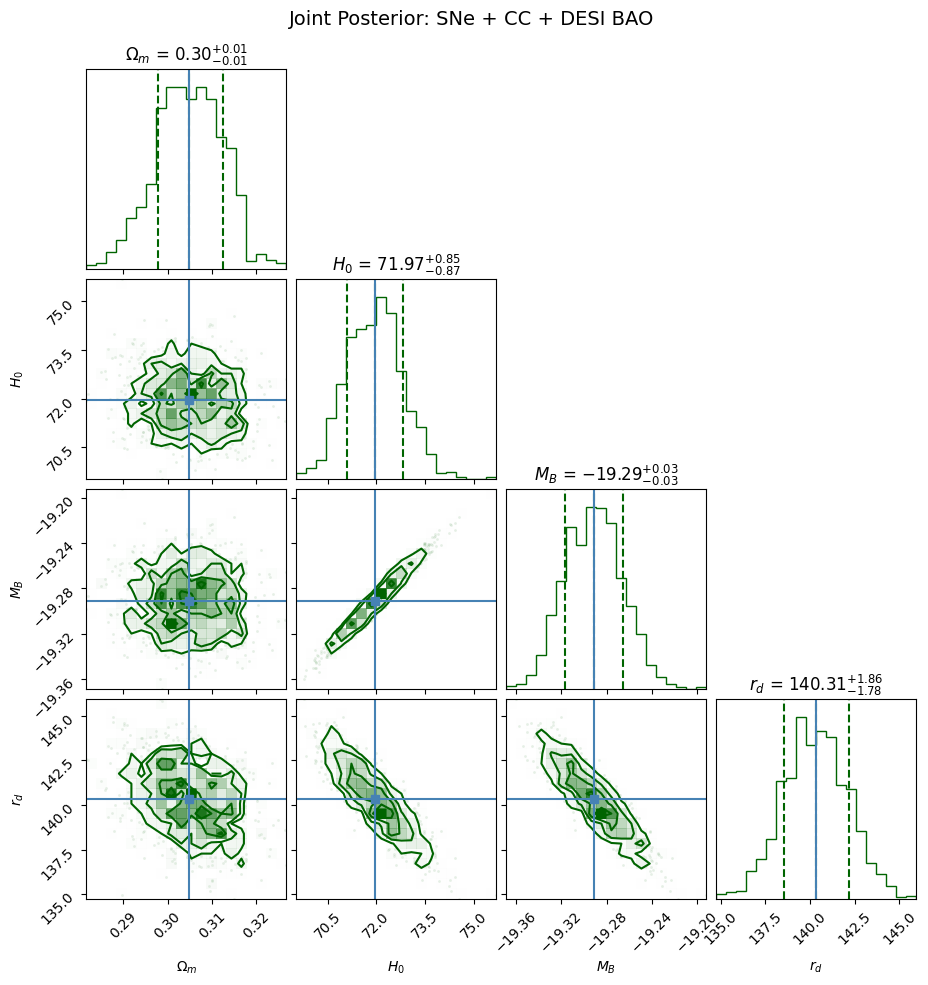

In [6]:
discard_steps = 300
thin_steps = 15
flat_samples = sampler.get_chain(discard=discard_steps, thin=thin_steps, flat=True)

labels = [r"$\Omega_m$", r"$H_0$", r"$M_B$", r"$r_d$"]
results = {}

print("\n--- JOINT Parameter Constraints (SN + CC + BAO) ---")
for i in range(ndim):
    mcmc_samples = flat_samples[:, i]
    median = np.percentile(mcmc_samples, 50)
    lower = median - np.percentile(mcmc_samples, 16)
    upper = np.percentile(mcmc_samples, 84) - median
    results[labels[i]] = median
    print(f"{labels[i]}: {median:.4f} +{upper:.4f} / -{lower:.4f}")

fig = corner.corner(
    flat_samples, 
    labels=labels, 
    truths=[results[r"$\Omega_m$"], results[r"$H_0$"], results[r"$M_B$"], results[r"$r_d$"]],
    quantiles=[0.16, 0.5, 0.84],
    show_titles=True,
    title_kwargs={"fontsize": 12},
    color='darkgreen'
)
plt.suptitle("Joint Posterior: SNe + CC + DESI BAO", y=1.02, fontsize=14)
plt.show()

Loaded chain with 1000 steps, 20 walkers, and 4 dimensions.


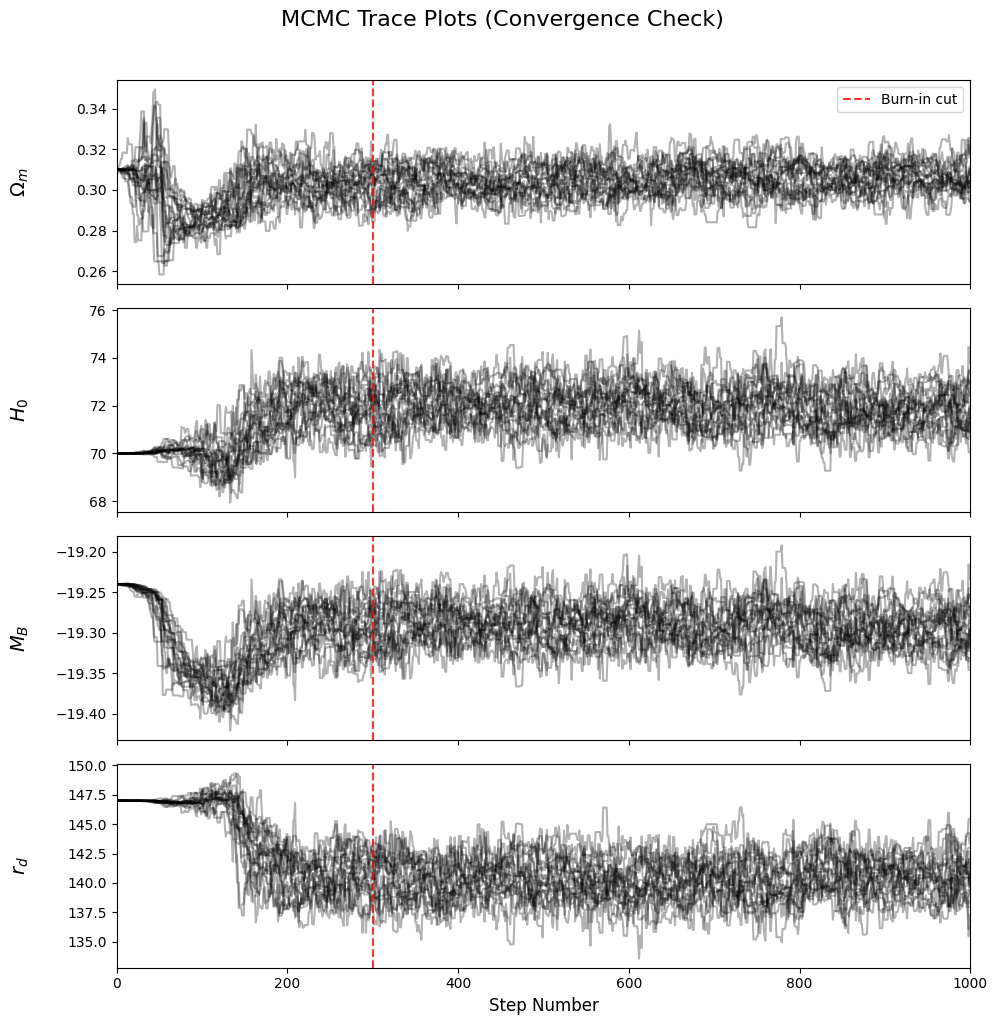

In [7]:
filename = "mcmc_chains/pantheon_cc_bao_mcmc_chain.h5" 

try:
    reader = emcee.backends.HDFBackend(filename)
    
    # get_chain() returns a 3D numpy array of shape: (nsteps, nwalkers, ndim)
    # We do NOT discard the burn-in here, because we want to see the whole history!
    chain = reader.get_chain()
    
    nsteps, nwalkers, ndim = chain.shape
    print(f"Loaded chain with {nsteps} steps, {nwalkers} walkers, and {ndim} dimensions.")
    
    # 2. Define labels based on the number of dimensions
    if ndim == 3:
        labels = [r"$\Omega_m$", r"$H_0$", r"$M_B$"]
    elif ndim == 4:
        labels = [r"$\Omega_m$", r"$H_0$", r"$M_B$", r"$r_d$"]
    else:
        labels = [f"Param {i}" for i in range(ndim)]

    # 3. Create the trace plots
    fig, axes = plt.subplots(ndim, figsize=(10, 2.5 * ndim), sharex=True)
    
    # If there's only 1 dimension, axes is not a list, so we wrap it
    if ndim == 1: axes = [axes]

    for i in range(ndim):
        ax = axes[i]
        # Plot the paths of all walkers for the i-th parameter.
        # "k" means black, alpha=0.3 makes the lines semi-transparent so we can see density
        ax.plot(chain[:, :, i], "k", alpha=0.3)
        ax.set_xlim(0, len(chain))
        ax.set_ylabel(labels[i], fontsize=14)
        ax.yaxis.set_label_coords(-0.1, 0.5)
        
        # Optional: Draw a vertical red dashed line to indicate your chosen burn-in
        burn_in_estimate = 300
        ax.axvline(x=burn_in_estimate, color='red', linestyle='--', alpha=0.8, label='Burn-in cut')
        if i == 0:
            ax.legend(loc='upper right')

    axes[-1].set_xlabel("Step Number", fontsize=12)
    plt.suptitle("MCMC Trace Plots (Convergence Check)", y=1.02, fontsize=16)
    plt.tight_layout()
    plt.show()

except FileNotFoundError:
    print(f"Error: The file {filename} could not be found. Make sure you ran the MCMC cell first.")